# DAY 1

In [6]:
import os
import pandas as pd
import numpy as np

In [7]:
print("Notebook cwd:", os.getcwd())
print("Files in ../data/raw:", os.listdir("../data/raw"))

Notebook cwd: c:\Users\Mansoor Kachhi\OneDrive\Desktop\ml-bigdata-analytics\notebooks
Files in ../data/raw: ['.gitkeep']


In [9]:
import os
print(os.listdir("../data/raw"))

['.gitkeep', 'yellow_tripdata_2015-01.csv']


In [12]:
DATA_PATH = "C:\\Users\\Mansoor Kachhi\\OneDrive\\Desktop\\ml-bigdata-analytics\\data\\raw\\yellow_tripdata_2015-01.csv"  # example
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (12748986, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [13]:
print(df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RateCodeID', 'store_and_fwd_flag', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']


In [14]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag           str
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

In [15]:
df.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80


In [16]:
df_sample = df.sample(n=300000, random_state=42)  # you can reduce to 100000 if slow
print(df_sample.shape)

(300000, 19)


In [17]:
TARGET = "total_amount"   # set this
print("Target dtype:", df_sample[TARGET].dtype)
print("Unique:", df_sample[TARGET].nunique())
print(df_sample[TARGET].value_counts().head(10))

Target dtype: float64
Unique: 3401
total_amount
6.8     9851
7.3     9246
8.3     9113
7.8     8838
9.8     8522
8.8     8158
6.3     7948
9.3     7583
5.8     6840
10.8    6438
Name: count, dtype: int64


In [18]:
# 1) Work on a sample for speed
df_sample = df.sample(n=300000, random_state=42).copy()
print("Sample shape:", df_sample.shape)

Sample shape: (300000, 19)


In [19]:
# 2) Create useful time features
df_sample["tpep_pickup_datetime"] = pd.to_datetime(df_sample["tpep_pickup_datetime"], errors="coerce")
df_sample["tpep_dropoff_datetime"] = pd.to_datetime(df_sample["tpep_dropoff_datetime"], errors="coerce")

df_sample["pickup_hour"] = df_sample["tpep_pickup_datetime"].dt.hour
df_sample["pickup_dayofweek"] = df_sample["tpep_pickup_datetime"].dt.dayofweek
df_sample["trip_duration_min"] = (
    (df_sample["tpep_dropoff_datetime"] - df_sample["tpep_pickup_datetime"]).dt.total_seconds() / 60
)

# Drop raw datetime columns after feature extraction
df_sample = df_sample.drop(columns=["tpep_pickup_datetime", "tpep_dropoff_datetime"])

In [20]:
# 3) Basic cleaning
df_sample = df_sample.drop_duplicates()

# Remove obviously broken rows
df_sample = df_sample[df_sample["trip_distance"] >= 0]
df_sample = df_sample[df_sample["fare_amount"] >= 0]
df_sample = df_sample[df_sample["total_amount"] >= 0]
df_sample = df_sample[df_sample["trip_duration_min"].notna()]
df_sample = df_sample[df_sample["trip_duration_min"] > 0]

# Fill nulls
for col in df_sample.select_dtypes(include=[np.number]).columns:
    df_sample[col] = df_sample[col].fillna(df_sample[col].median())

for col in df_sample.select_dtypes(exclude=[np.number]).columns:
    if df_sample[col].isnull().sum() > 0:
        df_sample[col] = df_sample[col].fillna(df_sample[col].mode()[0])

print("Remaining nulls:", df_sample.isnull().sum().sum())
print("Clean shape:", df_sample.shape)

Remaining nulls: 0
Clean shape: (299540, 20)


In [21]:
# 4) Regression baseline for total_amount
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET = "total_amount"

df_model = pd.get_dummies(df_sample, drop_first=True)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=120,
    max_depth=18,
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

RMSE: 0.8107
MAE : 0.0305
R²  : 0.9955


In [22]:
# 5) Save cleaned sample used for modeling
import os
os.makedirs("../data/processed", exist_ok=True)
df_sample.to_csv("../data/processed/day1_sample_clean.csv", index=False)
print("Saved: ../data/processed/day1_sample_clean.csv")

Saved: ../data/processed/day1_sample_clean.csv


# DAY 2

In [23]:
# Day 2 - Cell 1: make sure required columns exist
required_cols = [
    "trip_distance", "fare_amount", "tip_amount", "total_amount",
    "tpep_pickup_datetime", "tpep_dropoff_datetime"
]

missing = [c for c in required_cols if c not in df.columns]
print("Missing required columns:", missing)

Missing required columns: []


In [24]:
# Day 2 - Cell 2: work on sample for speed
df_sample = df.sample(n=300000, random_state=42).copy()
print("Sample shape:", df_sample.shape)

Sample shape: (300000, 19)


In [25]:
# Day 2 - Cell 3: datetime feature engineering
df_sample["tpep_pickup_datetime"] = pd.to_datetime(df_sample["tpep_pickup_datetime"], errors="coerce")
df_sample["tpep_dropoff_datetime"] = pd.to_datetime(df_sample["tpep_dropoff_datetime"], errors="coerce")

df_sample["pickup_hour"] = df_sample["tpep_pickup_datetime"].dt.hour
df_sample["pickup_dayofweek"] = df_sample["tpep_pickup_datetime"].dt.dayofweek
df_sample["trip_duration_min"] = (
    (df_sample["tpep_dropoff_datetime"] - df_sample["tpep_pickup_datetime"]).dt.total_seconds() / 60
)

# Drop raw datetime cols after extracting features
df_sample.drop(columns=["tpep_pickup_datetime", "tpep_dropoff_datetime"], inplace=True)

print("Datetime features added.")

Datetime features added.


In [26]:
# Day 2 - Cell 4: cleaning + sanity filters
import numpy as np

df_sample = df_sample.drop_duplicates()

# remove impossible/invalid values
df_sample = df_sample[df_sample["trip_distance"] >= 0]
df_sample = df_sample[df_sample["fare_amount"] >= 0]
df_sample = df_sample[df_sample["total_amount"] >= 0]
df_sample = df_sample[df_sample["trip_duration_min"].notna()]
df_sample = df_sample[df_sample["trip_duration_min"] > 0]
df_sample = df_sample[df_sample["passenger_count"] > 0]

# fill nulls
for col in df_sample.select_dtypes(include=[np.number]).columns:
    df_sample[col] = df_sample[col].fillna(df_sample[col].median())

for col in df_sample.select_dtypes(exclude=[np.number]).columns:
    if df_sample[col].isnull().sum() > 0:
        df_sample[col] = df_sample[col].fillna(df_sample[col].mode()[0])

print("Remaining nulls:", df_sample.isnull().sum().sum())
print("Clean shape:", df_sample.shape)

Remaining nulls: 0
Clean shape: (299354, 20)


In [27]:
# Day 2 - Cell 5: outlier clipping (1st to 99th percentile)
clip_cols = ["trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount", "trip_duration_min"]

for c in clip_cols:
    q1 = df_sample[c].quantile(0.01)
    q99 = df_sample[c].quantile(0.99)
    df_sample[c] = df_sample[c].clip(q1, q99)

print("Outlier clipping complete.")

Outlier clipping complete.


In [28]:
# Day 2 - Cell 6: train improved RF regressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET = "total_amount"

df_model = pd.get_dummies(df_sample, drop_first=True)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = mean_squared_error(y_test, preds) ** 0.5
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Day 2 RMSE: {rmse:.4f}")
print(f"Day 2 MAE : {mae:.4f}")
print(f"Day 2 R²  : {r2:.4f}")

Day 2 RMSE: 0.3575
Day 2 MAE : 0.0298
Day 2 R²  : 0.9990


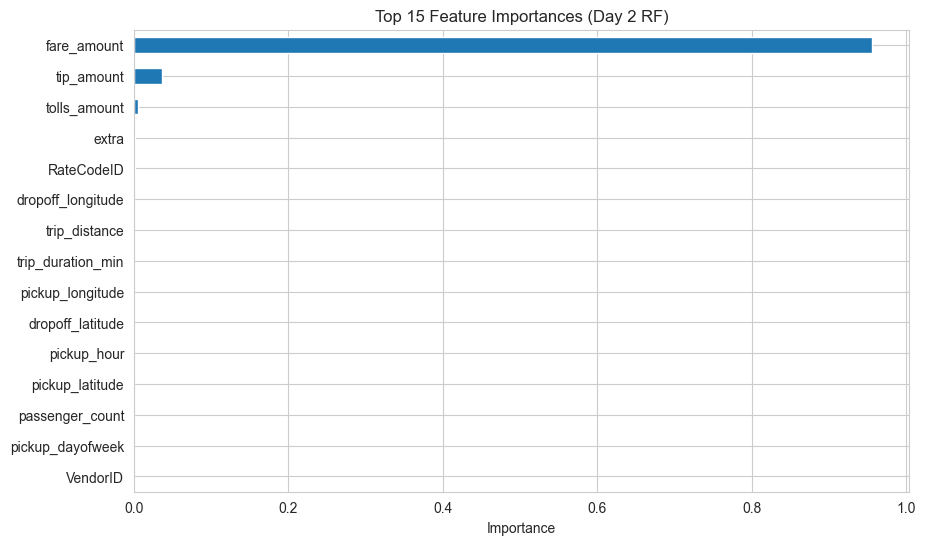

In [29]:
# Day 2 - Cell 7: feature importance (top 15)
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (Day 2 RF)")
plt.xlabel("Importance")
plt.show()

In [30]:
# Day 2 - Cell 8: save cleaned sample
import os
os.makedirs("../data/processed", exist_ok=True)
df_sample.to_csv("../data/processed/day2_sample_clean.csv", index=False)
print("Saved: ../data/processed/day2_sample_clean.csv")

Saved: ../data/processed/day2_sample_clean.csv


# DAY 3

In [31]:
# Day 3 - Cell 1: prepare train/test once
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

TARGET = "total_amount"

df_model = pd.get_dummies(df_sample, drop_first=True)
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (239483, 19) Test shape: (59871, 19)


In [32]:
# Day 3 - Cell 2: Random Forest (reference)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"RF -> RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f} | R²: {rf_r2:.4f}")

RF -> RMSE: 0.3575 | MAE: 0.0298 | R²: 0.9990


In [33]:
# Day 3 - Cell 3: HistGradientBoosting (fast strong baseline)
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_depth=12,
    max_iter=300,
    min_samples_leaf=30,
    random_state=42
)

hgb.fit(X_train, y_train)
hgb_preds = hgb.predict(X_test)

hgb_rmse = mean_squared_error(y_test, hgb_preds) ** 0.5
hgb_mae = mean_absolute_error(y_test, hgb_preds)
hgb_r2 = r2_score(y_test, hgb_preds)

print(f"HGB -> RMSE: {hgb_rmse:.4f} | MAE: {hgb_mae:.4f} | R²: {hgb_r2:.4f}")

HGB -> RMSE: 0.3673 | MAE: 0.0789 | R²: 0.9990


In [34]:
# Day 3 - Cell 4: comparison table
results = pd.DataFrame([
    {"Model": "RandomForestRegressor", "RMSE": rf_rmse, "MAE": rf_mae, "R2": rf_r2},
    {"Model": "HistGradientBoostingRegressor", "RMSE": hgb_rmse, "MAE": hgb_mae, "R2": hgb_r2},
]).sort_values("RMSE")

results

,Model,RMSE,MAE,R2
0,RandomForestRegressor,0.357460,0.029818,0.999008
1,HistGradientBoostingRegressor,0.367301,0.078947,0.998953


In [35]:
# Day 3 - Cell 5: pick winner
best_model_name = results.iloc[0]["Model"]
print("Best model by RMSE:", best_model_name)

Best model by RMSE: RandomForestRegressor


In [36]:
# Day 3 - Cell 6: save day-3 metrics artifact
import os
os.makedirs("../artifacts", exist_ok=True)
results.to_csv("../artifacts/day3_model_comparison.csv", index=False)
print("Saved: ../artifacts/day3_model_comparison.csv")

Saved: ../artifacts/day3_model_comparison.csv


# DAY 4

In [37]:
# Day 4 - Cell 1: quick RF hyperparameter sweep
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

param_grid = [
    {"n_estimators": 200, "max_depth": 20, "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 22, "min_samples_leaf": 2},
    {"n_estimators": 300, "max_depth": 24, "min_samples_leaf": 1},
    {"n_estimators": 400, "max_depth": 20, "min_samples_leaf": 1},
]

tuning_rows = []

for p in param_grid:
    model = RandomForestRegressor(
        n_estimators=p["n_estimators"],
        max_depth=p["max_depth"],
        min_samples_leaf=p["min_samples_leaf"],
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    tuning_rows.append({
        "n_estimators": p["n_estimators"],
        "max_depth": p["max_depth"],
        "min_samples_leaf": p["min_samples_leaf"],
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("RMSE").reset_index(drop=True)
tuning_df

,n_estimators,max_depth,min_samples_leaf,RMSE,MAE,R2
0,400,20,1,0.351503,0.026806,0.999041
1,200,20,2,0.357460,0.029818,0.999008
2,300,22,2,0.357654,0.029748,0.999007
3,300,24,1,0.358100,0.026949,0.999004


In [38]:
# Day 4 - Cell 2: choose best params
best_params = tuning_df.iloc[0][["n_estimators", "max_depth", "min_samples_leaf"]].to_dict()

best_params = {k: int(v) for k, v in best_params.items()}
print("Best params:", best_params)

Best params: {'n_estimators': 400, 'max_depth': 20, 'min_samples_leaf': 1}


In [39]:
# Day 4 - Cell 3: train final RF using best params
final_model = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    n_jobs=-1,
    random_state=42
)

final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)

final_rmse = mean_squared_error(y_test, final_preds) ** 0.5
final_mae = mean_absolute_error(y_test, final_preds)
final_r2 = r2_score(y_test, final_preds)

print(f"Final RF RMSE: {final_rmse:.6f}")
print(f"Final RF MAE : {final_mae:.6f}")
print(f"Final RF R²  : {final_r2:.6f}")

Final RF RMSE: 0.351503
Final RF MAE : 0.026806
Final RF R²  : 0.999041


In [40]:
# Day 4 - Cell 4: save model + metadata
import os, joblib, json
from datetime import datetime

os.makedirs("../artifacts", exist_ok=True)

joblib.dump(final_model, "../artifacts/final_model.pkl")

metadata = {
    "target": "total_amount",
    "model_type": "RandomForestRegressor",
    "best_params": best_params,
    "metrics": {
        "rmse": float(final_rmse),
        "mae": float(final_mae),
        "r2": float(final_r2)
    },
    "created_at": datetime.utcnow().isoformat() + "Z"
}

with open("../artifacts/final_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: ../artifacts/final_model.pkl")
print("Saved: ../artifacts/final_model_metadata.json")

Saved: ../artifacts/final_model.pkl
Saved: ../artifacts/final_model_metadata.json


C:\Users\Mansoor Kachhi\AppData\Local\Temp\ipykernel_19292\2534331563.py:18: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z"


In [41]:
# Day 4 - Cell 5: save tuning results
tuning_df.to_csv("../artifacts/day4_rf_tuning_results.csv", index=False)
print("Saved: ../artifacts/day4_rf_tuning_results.csv")

Saved: ../artifacts/day4_rf_tuning_results.csv


# DAY 5

In [42]:
# Day 5 - Cell 1: prepare training feature columns from current df_sample pipeline
# (This guarantees prediction data matches model input columns exactly)
TARGET = "total_amount"

train_model_df = pd.get_dummies(df_sample, drop_first=True)
train_feature_cols = [c for c in train_model_df.columns if c != TARGET]

print("Number of training features:", len(train_feature_cols))
print("Sample features:", train_feature_cols[:10])

Number of training features: 19
Sample features: ['VendorID', 'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude', 'RateCodeID', 'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount']


In [43]:
# Day 5 - Cell 2: create reusable preprocessing function for new data
import pandas as pd
import numpy as np

def preprocess_for_inference(raw_df: pd.DataFrame) -> pd.DataFrame:
    d = raw_df.copy()

    # datetime features
    d["tpep_pickup_datetime"] = pd.to_datetime(d["tpep_pickup_datetime"], errors="coerce")
    d["tpep_dropoff_datetime"] = pd.to_datetime(d["tpep_dropoff_datetime"], errors="coerce")

    d["pickup_hour"] = d["tpep_pickup_datetime"].dt.hour
    d["pickup_dayofweek"] = d["tpep_pickup_datetime"].dt.dayofweek
    d["trip_duration_min"] = (
        (d["tpep_dropoff_datetime"] - d["tpep_pickup_datetime"]).dt.total_seconds() / 60
    )

    # drop raw datetime columns
    d = d.drop(columns=["tpep_pickup_datetime", "tpep_dropoff_datetime"], errors="ignore")

    # basic validity filters (soft: keep rows, just fix invalids)
    if "trip_distance" in d.columns:
        d.loc[d["trip_distance"] < 0, "trip_distance"] = np.nan
    if "fare_amount" in d.columns:
        d.loc[d["fare_amount"] < 0, "fare_amount"] = np.nan
    if "trip_duration_min" in d.columns:
        d.loc[d["trip_duration_min"] <= 0, "trip_duration_min"] = np.nan
    if "passenger_count" in d.columns:
        d.loc[d["passenger_count"] <= 0, "passenger_count"] = np.nan

    # fill nulls
    for col in d.select_dtypes(include=[np.number]).columns:
        d[col] = d[col].fillna(d[col].median())

    for col in d.select_dtypes(exclude=[np.number]).columns:
        if d[col].isnull().sum() > 0:
            mode_val = d[col].mode()
            d[col] = d[col].fillna(mode_val.iloc[0] if len(mode_val) > 0 else "unknown")

    # one-hot encoding
    d = pd.get_dummies(d, drop_first=True)

    return d

In [44]:
# Day 5 - Cell 3: load the best model (from Day 4)
import joblib

model_path = "../artifacts/final_model.pkl"
final_model = joblib.load(model_path)
print("Loaded model:", model_path)

Loaded model: ../artifacts/final_model.pkl


In [46]:
# create a test inference file from existing dataset
df.head(1000).drop(columns=["total_amount"], errors="ignore").to_csv("../data/raw/new_trips.csv", index=False)
print("Created ../data/raw/new_trips.csv")

Created ../data/raw/new_trips.csv


In [47]:
# Day 5 - Cell 4: read new data and predict
# Put your new file at: ../data/raw/new_trips.csv
new_data_path = "../data/raw/new_trips.csv"

new_raw = pd.read_csv(new_data_path)
print("New raw shape:", new_raw.shape)

new_proc = preprocess_for_inference(new_raw)

# align inference dataframe to training columns
new_proc_aligned = new_proc.reindex(columns=train_feature_cols, fill_value=0)

predictions = final_model.predict(new_proc_aligned)
print("Predictions generated:", len(predictions))

New raw shape: (1000, 18)
Predictions generated: 1000


In [48]:
# Day 5 - Cell 5: save predictions
import os

os.makedirs("../artifacts", exist_ok=True)

pred_out = new_raw.copy()
pred_out["predicted_total_amount"] = predictions
pred_out.to_csv("../artifacts/predictions.csv", index=False)

print("Saved: ../artifacts/predictions.csv")
pred_out.head()

Saved: ../artifacts/predictions.csv


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,predicted_total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.050000
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.800000
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.800000
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.684207
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.300000


# DAY 6

In [49]:
from datetime import datetime, UTC
import matplotlib.pyplot as plt

In [51]:
import os
import matplotlib.pyplot as plt

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# X, y should already exist from your preprocessing cell
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [54]:
# --- Day 6: diagnostic plots ---
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.25, s=10)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("Actual total_amount")
plt.ylabel("Predicted total_amount")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "day6_actual_vs_pred.png"), dpi=150)
plt.close()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=60)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "day6_residual_distribution.png"), dpi=150)
plt.close()